In [3]:
import pandas as pd
import numpy as np
import joblib

from rdkit import Chem
from rdkit.Chem import AllChem

In [4]:
rf_tc = joblib.load("rf_tc.pkl")
rf_tg = joblib.load("rf_tg.pkl")
rf_density = joblib.load("rf_density.pkl")
rf_ffv = joblib.load("rf_ffv.pkl")
rf_rg = joblib.load("rf_rg.pkl")

print("Models loaded successfully")

Models loaded successfully


In [5]:
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential
import pandas as pd

# Connect to Azure ML workspace
ml_client = MLClient.from_config(
    credential=DefaultAzureCredential()
)

# Get PI1M dataset
pi1m_asset = ml_client.data.get(
    name="PI1M",
    version="1"
)

print("PI1M base path:", pi1m_asset.path)

# ✅ FIX: add "/" before filename
pi1m_csv_path = pi1m_asset.path + "/PI1M.csv"

print("Full CSV path:", pi1m_csv_path)

# Load dataframe
pi1m_df = pd.read_csv(pi1m_csv_path)

print("PI1M shape:", pi1m_df.shape)
pi1m_df.head()



Found the config file in: /config.json
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/mlflow/__init__.py:41: UserWarning: Versions of mlflow (3.1.1) and mlflow-skinny (2.22.1) are different. This may lead to unexpected behavior. Please install the same version of both packages.
  mlflow.mismatch._check_version_mismatch()


PI1M base path: azureml://subscriptions/05089bc0-764a-404d-893e-2fc1f23863ab/resourcegroups/polymers/workspaces/poymerblends/datastores/workspaceblobstore/paths/UI/2026-01-28_125530_UTC/PI1M/
Full CSV path: azureml://subscriptions/05089bc0-764a-404d-893e-2fc1f23863ab/resourcegroups/polymers/workspaces/poymerblends/datastores/workspaceblobstore/paths/UI/2026-01-28_125530_UTC/PI1M//PI1M.csv
PI1M shape: (999988, 1)


,SMILES
0,*/CCC[Fe]CCCC(=O)OCCCCOCCCNCC(*)=O
1,*CCCC1CCCC(*)c2ccc2Ncc1
2,*CCC/*
3,*C(=O)CNC(*)C(=O)OCCCCCNC
4,*CC(C)(C)CCCCCCC(C)C(=O)N*


In [6]:
sample_df = pi1m_df.head(10)

print("Number of polymers selected:", len(sample_df))

Number of polymers selected: 10


In [7]:
import joblib

models = {
    "Tc": joblib.load("rf_tc.pkl"),
    "Tg": joblib.load("rf_tg.pkl"),
    "Density": joblib.load("rf_density.pkl"),
    "FFV": joblib.load("rf_ffv.pkl"),
    "Rg": joblib.load("rf_rg.pkl"),
}

for name, model in models.items():
    print(name, "expects", model.n_features_in_, "features")

Tc expects 2048 features
Tg expects 2048 features
Density expects 2048 features
FFV expects 2048 features
Rg expects 2048 features


In [8]:
from inference import smiles_to_fingerprint

fp = smiles_to_fingerprint(pi1m_df["SMILES"].iloc[0])

print(fp.shape)

(1, 2048)


In [9]:
import importlib
import inference

importlib.reload(inference)

from inference import predict_properties, check_sustainability

In [10]:
test_smiles = pi1m_df["SMILES"].iloc[0]

pred = predict_properties(test_smiles)

print(pred)

{'Tc': 0.183407777777778, 'Tg': 21.23129196673432, 'Density': 1.037058372989422, 'FFV': 0.3475116215361117, 'Rg': 13.316833789972646}


In [11]:
from inference import predict_properties, check_sustainability

sample_df = pi1m_df.head(10)

results = []

for i, smiles in enumerate(sample_df["SMILES"]):

    pred = predict_properties(smiles)

    if pred is None or "error" in pred:
        print(f"Skipping invalid SMILES at index {i}")
        continue

    sustainability = check_sustainability(pred)

    results.append({
        "SMILES": smiles,
        "Tc": pred["Tc"],
        "Tg": pred["Tg"],
        "Density": pred["Density"],
        "FFV": pred["FFV"],
        "Rg": pred["Rg"],
        "Sustainability": sustainability
    })

    print(f"Processed polymer {i+1}")

result_df = pd.DataFrame(results)

result_df


Processed polymer 1
Processed polymer 2
Processed polymer 3
Processed polymer 4
Processed polymer 5
Processed polymer 6
Processed polymer 7
Processed polymer 8
Processed polymer 9
Processed polymer 10


,SMILES,Tc,Tg,Density,FFV,Rg,Sustainability
0,*/CCC[Fe]CCCC(=O)OCCCCOCCCNCC(*)=O,0.183408,21.231292,1.037058,0.347512,13.316834,Not Sustainable
1,*CCCC1CCCC(*)c2ccc2Ncc1,0.218703,48.709631,0.910636,0.403248,13.716650,Sustainable
2,*CCC/*,0.218120,3.637216,0.829535,0.407988,13.401359,Sustainable
3,*C(=O)CNC(*)C(=O)OCCCCCNC,0.306255,18.874888,0.976800,0.343421,13.211726,Not Sustainable
4,*CC(C)(C)CCCCCCC(C)C(=O)N*,0.342122,13.446201,0.923398,0.352690,17.919307,Sustainable
5,*Oc1ccc(CCCNC(=O)NCCCC(=O)C(C)C(*)=O)cc1,0.233792,35.979662,1.034715,0.342010,15.479569,Not Sustainable
6,*CCCCC*,0.369316,-4.188451,0.845362,0.407567,13.322026,Sustainable
7,*CC(*)C(C)(C)CCC,0.211767,24.738039,0.821283,0.414219,16.835300,Sustainable
8,*CC(*)(C)CC=O,0.212941,43.179471,0.976754,0.383495,17.695703,Sustainable
9,*Oc1ccc(*)cc1O,0.196651,129.690837,0.986010,0.367883,15.722894,Sustainable


In [28]:
from inference import predict_properties, check_sustainability
import pandas as pd

results = []

total = len(pi1m_df)

print("Total polymers:", total)

for i, smiles in enumerate(pi1m_df["SMILES"]):

    pred = predict_properties(smiles)

    if pred is None:
        continue

    sustainability = check_sustainability(pred)

    row = {
        "SMILES": smiles,
        "Tc": pred["Tc"],
        "Tg": pred["Tg"],
        "Density": pred["Density"],
        "FFV": pred["FFV"],
        "Rg": pred["Rg"],
        "Sustainability": sustainability
    }

    results.append(row)

    # Progress update
    if (i+1) % 10000 == 0:
        print(f"Processed {i+1} polymers")

# Convert to dataframe
result_df = pd.DataFrame(results)

# Save CSV
result_df.to_csv("new_sustainability.csv", index=False)

print("Prediction completed")
print("Saved file: new_sustainability.csv")
print("Total predicted:", len(result_df))

Total polymers: 999988


In [12]:
A_df = pi1m_df.iloc[0:10]
B_df = pi1m_df.iloc[10:20]

print("A size:", len(A_df))
print("B size:", len(B_df))

A size: 10
B size: 10


In [14]:
from inference import predict_blend_with_sustainability

smi_a = A_df["SMILES"].iloc[0]
smi_b = B_df["SMILES"].iloc[0]

test_blend = predict_blend_with_sustainability(smi_a, smi_b, w=0.5)

print(test_blend)

{'Tc': 0.218861888888889, 'Tg': -4.350096445319002, 'Density': 0.9758899506300952, 'FFV': 0.354909458981111, 'Rg': 13.578863388476687, 'Sustainability': 'Sustainable'}


In [15]:
from inference import predict_blend_with_sustainability
import pandas as pd

rows = []
WEIGHT = 0.5

count = 0

for smi_a in A_df["SMILES"]:
    for smi_b in B_df["SMILES"]:

        blend_pred = predict_blend_with_sustainability(smi_a, smi_b, w=WEIGHT)

        if "error" in blend_pred:
            continue

        rows.append({
            "SMILES_A": smi_a,
            "SMILES_B": smi_b,
            "Weight_A": WEIGHT,
            "Weight_B": 1-WEIGHT,
            "Tc": blend_pred["Tc"],
            "Tg": blend_pred["Tg"],
            "Density": blend_pred["Density"],
            "FFV": blend_pred["FFV"],
            "Rg": blend_pred["Rg"],
            "Sustainability": blend_pred["Sustainability"]
        })

        count += 1

        if count == 10:
            break

    if count == 10:
        break

blend_df = pd.DataFrame(rows)

blend_df

,SMILES_A,SMILES_B,Weight_A,Weight_B,Tc,Tg,Density,FFV,Rg,Sustainability
0,*/CCC[Fe]CCCC(=O)OCCCCOCCCNCC(*)=O,*CC(*)COCCCCC(C)=O,0.5,0.5,0.218862,-4.350096,0.975890,0.354909,13.578863,Sustainable
1,*/CCC[Fe]CCCC(=O)OCCCCOCCCNCC(*)=O,*O*,0.5,0.5,0.202820,74.778470,0.883812,0.388047,14.329087,Sustainable
2,*/CCC[Fe]CCCC(=O)OCCCCOCCCNCC(*)=O,*C(=O)O*,0.5,0.5,0.213158,89.128207,0.964848,0.338894,14.051822,Sustainable
3,*/CCC[Fe]CCCC(=O)OCCCCOCCCNCC(*)=O,*Cc1ccc(C(=O)OCCCCCOC(=O)OCCCCCCC(=O)C(*)=O)cc1,0.5,0.5,0.218921,-0.868743,0.973509,0.356614,13.397456,Sustainable
4,*/CCC[Fe]CCCC(=O)OCCCCOCCCNCC(*)=O,*CCN(CF)c1ccc(*)cc1,0.5,0.5,0.215770,35.716495,0.840806,0.402244,13.873923,Sustainable
5,*/CCC[Fe]CCCC(=O)OCCCCOCCCNCC(*)=O,*CN(*)c1ccc1,0.5,0.5,0.209755,37.042073,0.841781,0.396975,14.046094,Sustainable
6,*/CCC[Fe]CCCC(=O)OCCCCOCCCNCC(*)=O,*Oc1c(C)c(C)c(S(=O)/c2ccc(*)cc2OC)cc1,0.5,0.5,0.204225,81.351324,1.012840,0.371275,14.248053,Sustainable
7,*/CCC[Fe]CCCC(=O)OCCCCOCCCNCC(*)=O,*OC(=O)CCCCCOC(=O)O*,0.5,0.5,0.224529,7.500604,0.986401,0.336109,13.418972,Not Sustainable
8,*/CCC[Fe]CCCC(=O)OCCCCOCCCNCC(*)=O,*C(=O)/C(*)=O,0.5,0.5,0.206899,85.792852,0.961172,0.364562,14.022552,Sustainable
9,*/CCC[Fe]CCCC(=O)OCCCCOCCCNCC(*)=O,*CCCOC(=O)Nc1ccc(C(*)=O)cc1OC,0.5,0.5,0.226846,17.201636,0.922808,0.348378,13.025254,Not Sustainable


In [ ]:
A_df = pi1m_df.iloc[0:50]     # 50 polymers
B_df = pi1m_df.iloc[50:70]    # 20 polymers

rows = []
WEIGHT_A = 0.5
WEIGHT_B = 1 - WEIGHT_A   # automatically calculate

for smi_a in A_df["SMILES"]:
    for smi_b in B_df["SMILES"]:

        blend_pred = predict_blend_with_sustainability(
            smi_a, smi_b, w=WEIGHT_A
        )

        if not blend_pred or "error" in blend_pred:
            continue

        rows.append({
            "SMILES_A": smi_a,
            "SMILES_B": smi_b,
            "Weight_A": WEIGHT_A,
            "Weight_B": WEIGHT_B,   # ✅ added
            "Tc": blend_pred["Tc"],
            "Tg": blend_pred["Tg"],
            "Density": blend_pred["Density"],
            "FFV": blend_pred["FFV"],
            "Rg": blend_pred["Rg"],
            "Sustainability": blend_pred["Sustainability"]
        })

blend_df = pd.DataFrame(rows)

print("Total blends:", len(blend_df))

blend_df.to_csv("blend_results.csv", index=False)


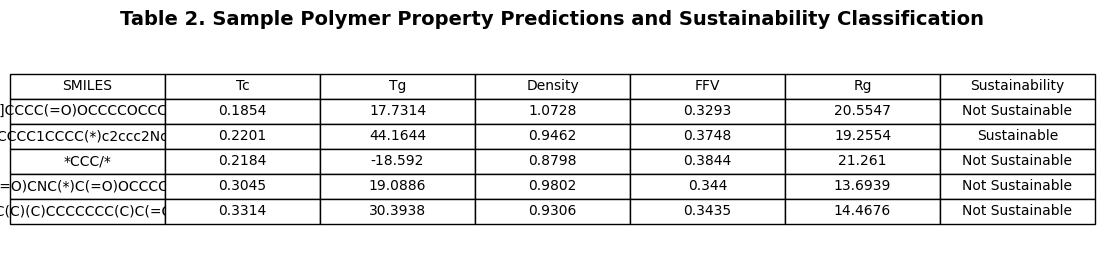

Saved as sample_predictions_table.png


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load full predictions
df = pd.read_csv("sustainability.csv")

# Select first 5 samples
sample_df = df[["SMILES","Tc","Tg","Density","FFV","Rg","Sustainability"]].head(5)

# Create table figure
fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')

table = ax.table(
    cellText=sample_df.round(4).values,
    colLabels=sample_df.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.title(
    "Table 2. Sample Polymer Property Predictions and Sustainability Classification",
    fontsize=14,
    weight='bold'
)

# Save as PNG
plt.savefig("sample_predictions_table.png", dpi=300, bbox_inches='tight')
plt.show()

print("Saved as sample_predictions_table.png")

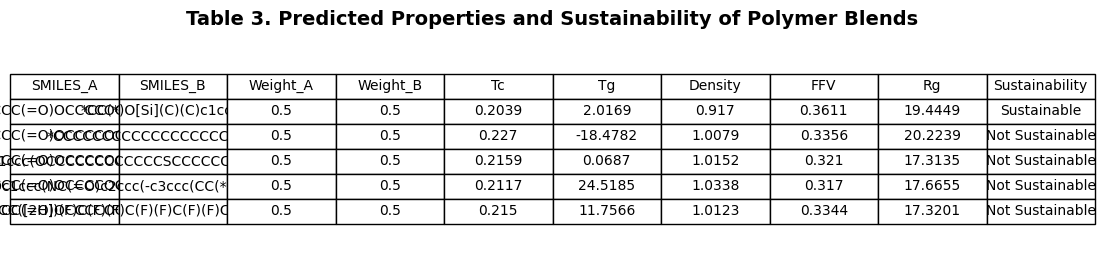

Saved as blend_predictions_table2.png


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Load blend results
blend_df = pd.read_csv("blend_results.csv")

# Take first 5 blends
sample_blend = blend_df.head(5)

# Select important columns
sample_blend = sample_blend[
    ["SMILES_A","SMILES_B","Weight_A","Weight_B","Tc","Tg","Density","FFV","Rg","Sustainability"]
]

# Create figure
fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')

table = ax.table(
    cellText=sample_blend.round(4).values,
    colLabels=sample_blend.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.title(
    "Table 3. Predicted Properties and Sustainability of Polymer Blends",
    fontsize=14,
    weight='bold'
)

# Save
plt.savefig("blend_predictions_table.png", dpi=300, bbox_inches='tight')
plt.show()

print("Saved as blend_predictions_table2.png")

Total rows: 999988


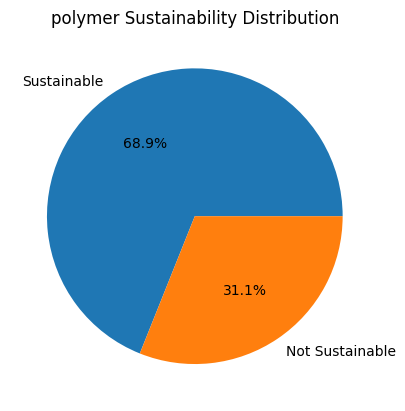

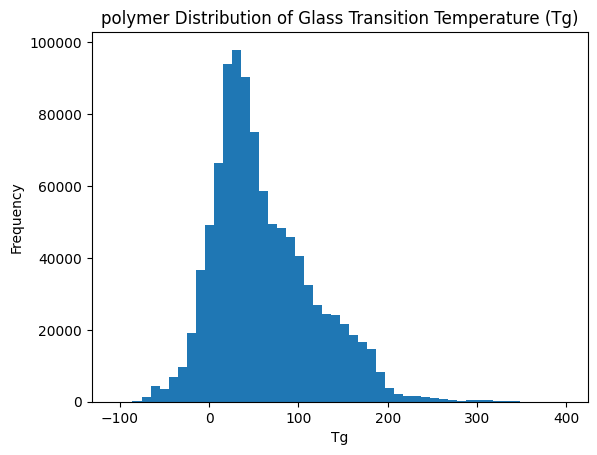

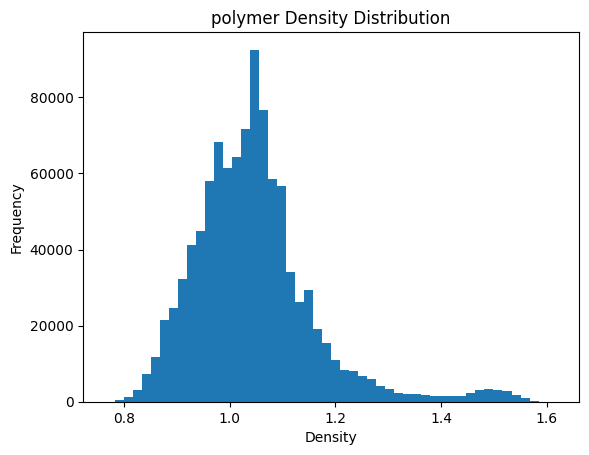

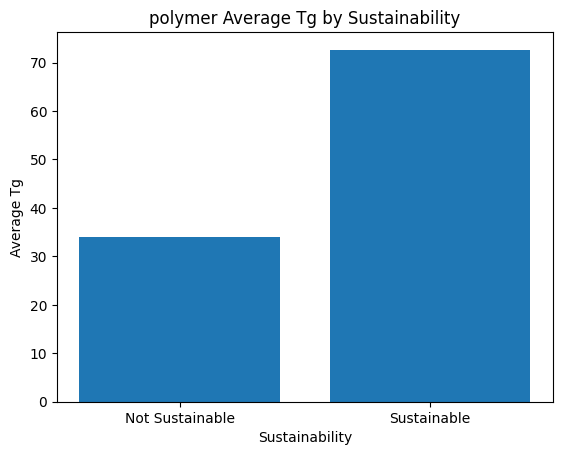

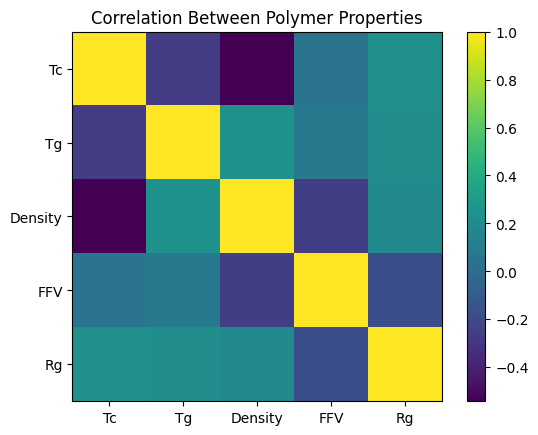

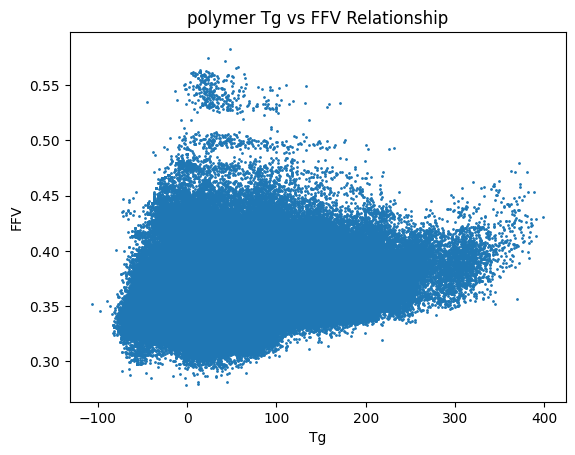

✅ All graphs saved successfully!


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("sustainability.csv")

print("Total rows:", len(df))


# =========================
# Graph 1: Sustainability Pie Chart
# =========================

counts = df["Sustainability"].value_counts()

plt.figure()
plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
plt.title("polymer Sustainability Distribution")
plt.savefig("polymer sustainability_pie.png", dpi=300, bbox_inches="tight")
plt.show()



# =========================
# Graph 2: Tg Distribution Histogram
# =========================

plt.figure()
plt.hist(df["Tg"], bins=50)
plt.title("polymer Distribution of Glass Transition Temperature (Tg)")
plt.xlabel("Tg")
plt.ylabel("Frequency")
plt.savefig("polymer tg_distribution.png", dpi=300, bbox_inches="tight")
plt.show()



# =========================
# Graph 3: Density Distribution Histogram
# =========================

plt.figure()
plt.hist(df["Density"], bins=50)
plt.title("polymer Density Distribution")
plt.xlabel("Density")
plt.ylabel("Frequency")
plt.savefig("polymer density_distribution.png", dpi=300, bbox_inches="tight")
plt.show()



# =========================
# Graph 4: Sustainability vs Tg (Bar Chart)
# =========================

avg_tg = df.groupby("Sustainability")["Tg"].mean()

plt.figure()
plt.bar(avg_tg.index, avg_tg.values)
plt.title("polymer Average Tg by Sustainability")
plt.xlabel("Sustainability")
plt.ylabel("Average Tg")
plt.savefig("polymer sustainability_vs_tg.png", dpi=300, bbox_inches="tight")
plt.show()



# =========================
# Graph 5: Correlation Heatmap
# =========================

corr = df[["Tc", "Tg", "Density", "FFV", "Rg"]].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Between Polymer Properties")

plt.savefig("polymer correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()



# =========================
# Graph 6: Tg vs FFV Scatter Plot
# =========================

plt.figure()
plt.scatter(df["Tg"], df["FFV"], s=1)
plt.title("polymer Tg vs FFV Relationship")
plt.xlabel("Tg")
plt.ylabel("FFV")

plt.savefig("polymer tg_vs_ffv.png", dpi=300, bbox_inches="tight")
plt.show()



print("✅ All graphs saved successfully!")

Total rows: 1000


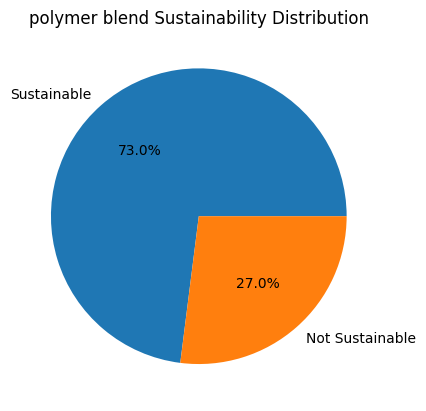

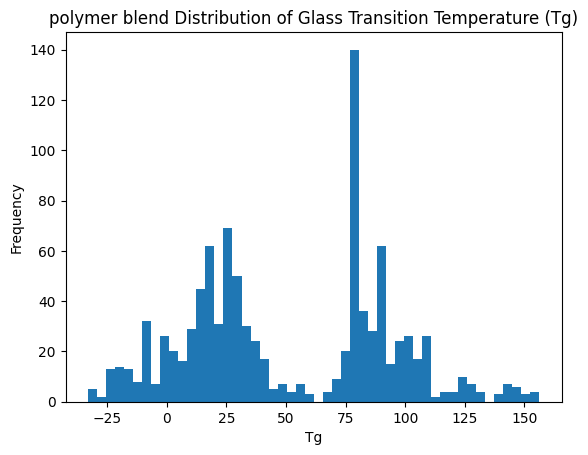

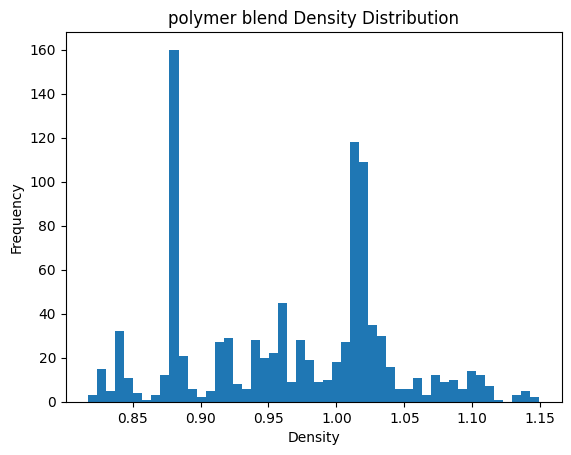

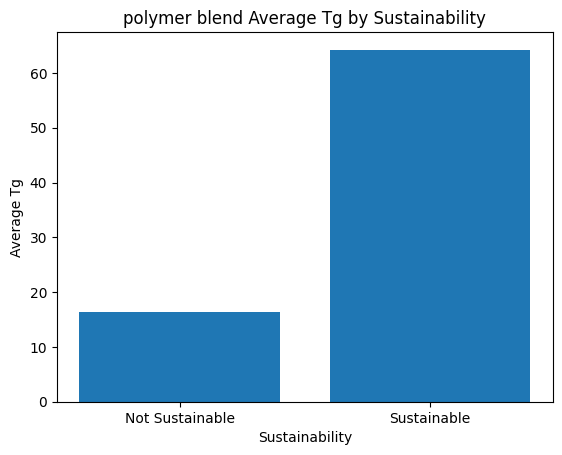

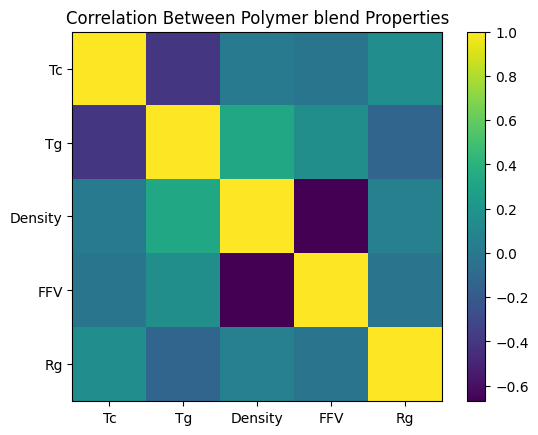

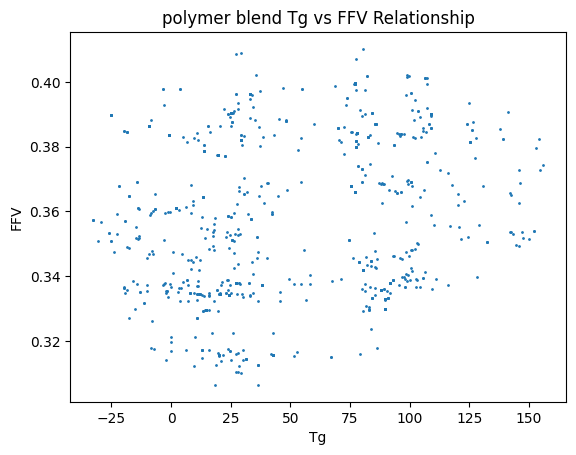

✅ All graphs saved successfully!


In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("blend_results.csv")

print("Total rows:", len(df))


# =========================
# Graph 1: Sustainability Pie Chart
# =========================

counts = df["Sustainability"].value_counts()

plt.figure()
plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
plt.title("polymer blend Sustainability Distribution")
plt.savefig("polymer blend sustainability_pie.png", dpi=300, bbox_inches="tight")
plt.show()



# =========================
# Graph 2: Tg Distribution Histogram
# =========================

plt.figure()
plt.hist(df["Tg"], bins=50)
plt.title("polymer blend Distribution of Glass Transition Temperature (Tg)")
plt.xlabel("Tg")
plt.ylabel("Frequency")
plt.savefig("polymer blend tg_distribution.png", dpi=300, bbox_inches="tight")
plt.show()



# =========================
# Graph 3: Density Distribution Histogram
# =========================

plt.figure()
plt.hist(df["Density"], bins=50)
plt.title("polymer blend Density Distribution")
plt.xlabel("Density")
plt.ylabel("Frequency")
plt.savefig("polymer blend density_distribution.png", dpi=300, bbox_inches="tight")
plt.show()



# =========================
# Graph 4: Sustainability vs Tg (Bar Chart)
# =========================

avg_tg = df.groupby("Sustainability")["Tg"].mean()

plt.figure()
plt.bar(avg_tg.index, avg_tg.values)
plt.title("polymer blend Average Tg by Sustainability")
plt.xlabel("Sustainability")
plt.ylabel("Average Tg")
plt.savefig("polymer blend sustainability_vs_tg.png", dpi=300, bbox_inches="tight")
plt.show()



# =========================
# Graph 5: Correlation Heatmap
# =========================

corr = df[["Tc", "Tg", "Density", "FFV", "Rg"]].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Between Polymer blend Properties")

plt.savefig("polymer blendcorrelation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()



# =========================
# Graph 6: Tg vs FFV Scatter Plot
# =========================

plt.figure()
plt.scatter(df["Tg"], df["FFV"], s=1)
plt.title("polymer blend Tg vs FFV Relationship")
plt.xlabel("Tg")
plt.ylabel("FFV")

plt.savefig("polymer blend tg_vs_ffv.png", dpi=300, bbox_inches="tight")
plt.show()



print("✅ All graphs saved successfully!")